### [ 주제 : 소리 → 멜 스펙트로그램 전처리 ]
- **[1] 변환 설정 및 함수 정의**
- **[2] 전체 wav 파일 변환**
- **[3] .npy 저장 및 검증**

> 각 셀의 TODO 힌트를 보고 코드를 직접 작성한다.
> 막히면 Claude와의 대화에 있는 완성 코드를 참고한다.

**[0] 사전준비**
- 모듈 로딩
- 변환 설정 상수
- 저장 폴더 생성

In [2]:
## 모듈 로딩
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt


In [3]:
## => 멜 스펙트로그램 변환 설정 (MIMII 논문 베이스라인과 동일)
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 512

## => 데이터 경로 관련
DATA_DIR = '../data/slider'
SAVE_DIR = '../data/processed/slider'
MACHINE_IDS = ['id_00','id_02','id_04','id_06']
LABELS = ['normal','abnormal']

## => 저장 폴더 체크 및 생성
os.makedirs(SAVE_DIR,exist_ok=True)


**[1] 변환 함수 정의**

01번 노트북에서 했던 변환(load → melspectrogram → power_to_db)을
4,094번 반복할 것이므로 함수로 묶는다.

In [4]:
## -> 함수 기능 : wav 파일 1개를 멜 스펙트로그램(dB) 배열로 변환
## -> 함수 이름 : wav_to_mel
## -> 매개 변수 : file_path - wav 파일 경로
## -> 함수 결과 : (64, 313) 크기 ndarray
def wav_to_mel(file_path):
    y, sr = librosa.load(file_path,sr=None)
    mel = librosa.feature.melspectrogram(y=y,sr=sr,n_mels=N_MELS,
                                         n_fft=N_FFT,hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel)
    
    return mel_db


In [7]:
## => 전체 실행 전에 파일 1개로 함수 테스트
testNP = wav_to_mel(f'{DATA_DIR}/id_00/normal/00000000.wav')
print(f'반환결과 : {testNP.shape}')


반환결과 : (64, 313)


**[2] 전체 wav 파일 변환**

구조 : 기계(4대) → 라벨(2종) → 파일(수백 개)의 **3중 for문**

결과물 : `data/processed/slider/` 에 `기계_라벨.npy` 8개 파일

⏱️ 전체 4,094개 파일이라 **5~10분** 걸린다. 진행 상황 print를 보면서 기다리기.

In [10]:
## => 기계 4대 x 라벨 2종 = 8개 조합 반복 처리

for machine_id in MACHINE_IDS:
    for label in LABELS:
        FOLDER = f'{DATA_DIR}/{machine_id}/{label}'
        filelist = os.listdir(FOLDER)
        filelist.sort()
        print(f'\n{machine_id}/{label}파일 : {len(filelist)}개')
        
        mel_list = []
        for i in range(len(filelist)):
            mel_db = wav_to_mel(f'{FOLDER}/{filelist[i]}')
            mel_list.append(mel_db)
            if i % 200 == 0:
                print(f'진행 : {i}/{len(filelist)}')
        
        resultNP = np.array(mel_list)
        SAVE_PATH = f'{SAVE_DIR}/{machine_id}_{label}.npy'
        np.save(SAVE_PATH, resultNP)
        print(f'저장 완료 : {SAVE_PATH} {resultNP.shape}')


id_00/normal파일 : 1068개
진행 : 0/1068
진행 : 200/1068
진행 : 400/1068
진행 : 600/1068
진행 : 800/1068
진행 : 1000/1068
저장 완료 : ../data/processed/slider/id_00_normal.npy (1068, 64, 313)

id_00/abnormal파일 : 356개
진행 : 0/356
진행 : 200/356
저장 완료 : ../data/processed/slider/id_00_abnormal.npy (356, 64, 313)

id_02/normal파일 : 1068개
진행 : 0/1068
진행 : 200/1068
진행 : 400/1068
진행 : 600/1068
진행 : 800/1068
진행 : 1000/1068
저장 완료 : ../data/processed/slider/id_02_normal.npy (1068, 64, 313)

id_02/abnormal파일 : 267개
진행 : 0/267
진행 : 200/267
저장 완료 : ../data/processed/slider/id_02_abnormal.npy (267, 64, 313)

id_04/normal파일 : 534개
진행 : 0/534
진행 : 200/534
진행 : 400/534
저장 완료 : ../data/processed/slider/id_04_normal.npy (534, 64, 313)

id_04/abnormal파일 : 178개
진행 : 0/178
저장 완료 : ../data/processed/slider/id_04_abnormal.npy (178, 64, 313)

id_06/normal파일 : 534개
진행 : 0/534
진행 : 200/534
진행 : 400/534
저장 완료 : ../data/processed/slider/id_06_normal.npy (534, 64, 313)

id_06/abnormal파일 : 89개
진행 : 0/89
저장 완료 : ../data/processed/slider/id

**[3] 저장 결과 검증**

저장된 npy를 다시 불러와서 shape과 그림을 확인한다.

| 파일 | 기대 shape |
|------|-----------|
| id_00_normal.npy | (1068, 64, 313) |
| id_00_abnormal.npy | (356, 64, 313) |

In [11]:
## => 저장된 npy 다시 불러와서 shape 확인
normalNP = np.load(f'{SAVE_DIR}/id_00_normal.npy')
abnormalNP = np.load(f'{SAVE_DIR}/id_00_abnormal.npy')

print(f'정상 데이터 : {normalNP.shape}')
print(f'이상 데이터 : {abnormalNP.shape}')

정상 데이터 : (1068, 64, 313)
이상 데이터 : (356, 64, 313)


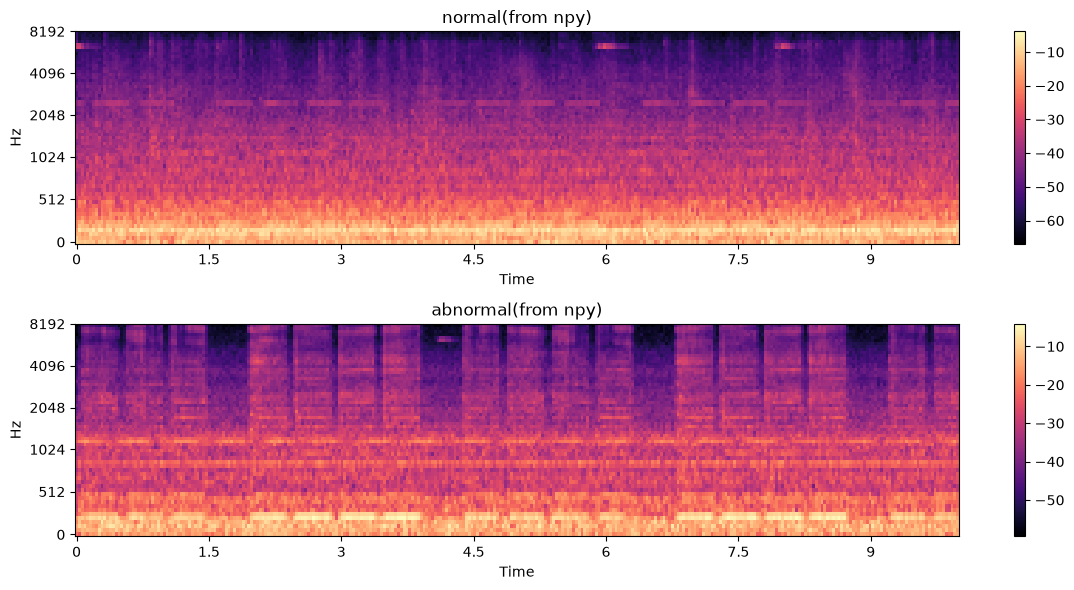

In [ ]:
## => 그림으로 재확인 : 01번 노트북에서 본 스펙트로그램과 같은 모양인지
plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
librosa.display.specshow(normalNP[0], sr=16000, hop_length=HOP_LENGTH,x_axis='time',y_axis='mel')

plt.colorbar()
plt.title('normal(from npy)')

plt.subplot(2,1,2)
librosa.display.specshow(abnormalNP[0], sr=16000, hop_length=HOP_LENGTH,x_axis='time',y_axis='mel')

plt.colorbar()
plt.title('abnormal(from npy)')

plt.tight_layout()
plt.show()

## 다음 단계

- 8개 npy 파일이 모두 저장됐으면 전처리(진행 계획 2단계) 완료
- 다음 노트북(03)에서는 **AutoEncoder 모델을 만들어 정상 소리만으로 학습**한다
  - 수업 자료 참고 : `[9]DL/Day02` (Dataset 클래스), `[9]DL/Day04` (학습 함수)
